In [1]:
from getdist import loadMCSamples
import getdist.plots as plots
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Set Main Chain Dictionary
chains = {}
models = {}
chain_dir = Path(r'/home/theppawan/cosmo-research/quintom-project/chains')
chain_prefixes = [p.with_suffix('') for p in chain_dir.rglob('*.checkpoint')]

for prefix_path in chain_prefixes:
    chain_name = prefix_path.name
    model, dataset = chain_name.split("_", 1)

    # Set model label
    if 'lcdm' in model:
        models_label = r'\Lambda {\rm CDM}'
    else:
        models_label = model.capitalize()
    models[model] = models_label

    # Set dataset label
    if 'theta' in dataset:
        label = dataset.replace("theta", r"$\theta_*$")
    else:
        label = dataset
    chains[chain_name] = [str(prefix_path), rf"{label}", models_label]

# Sub-Dictionary
lcdm_chains = {key: chains[key] for key in chains.keys() if 'lcdm' in key}
quintom_chains = {key: chains[key] for key in chains.keys() if 'quintom' in key}

In [4]:
chains['lcdm_DESI+BBN'][1]

'DESI+BBN'

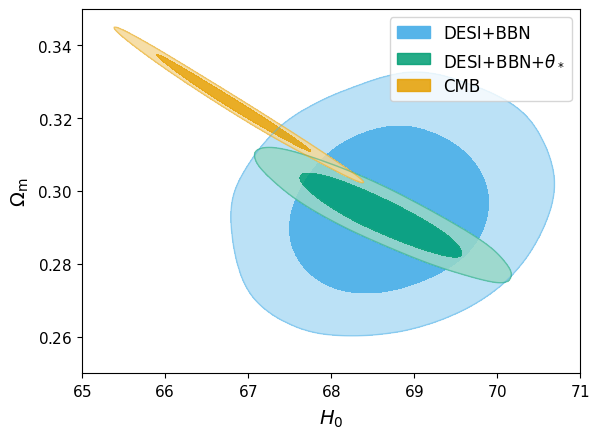

In [6]:
chains_to_extract = ['lcdm_DESI+BBN', 'lcdm_DESI+BBN+theta', 'lcdm_CMB']

# Creates the dict only if the key exists in the original
chain_samples_1 = {k: chains[k] for k in chains_to_extract if k in chains}

plot_settings = plots.GetDistPlotSettings()

# Visual Tweaks for Publications
plot_settings.figure_legend_frame = False  # Removes the box around the legend
plot_settings.alpha_filled_add = 0.85      # Adjust transparency of filled contours

g = plots.get_single_plotter(settings=plot_settings)

# Your existing plot_2d function
g.plot_2d([chains['lcdm_DESI+BBN'][0], chains['lcdm_DESI+BBN+theta'][0], chains['lcdm_CMB'][0]],
          'H0',
          'Omega_m',
          filled=True,
          colors=["#56B4E9", "#009E73", "#E69F00"]
         )

# Explicitly add the legend here
labels = [chains['lcdm_DESI+BBN'][1], chains['lcdm_DESI+BBN+theta'][1], chains['lcdm_CMB'][1]]
g.add_legend(labels, legend_loc='upper right') # You can adjust the location

plt.xlim(65, 71)
plt.ylim(0.25, 0.35)
plt.show()